In [3]:
%pip install matplotlib
%pip install librosa
%pip install scipy
import numpy as np
import matplotlib.pyplot as plt


  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 8.4 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 10.5 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 12.0 MB/s  0:00:00
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 19.0 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.3 MB 7.0 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/12.3 MB 11.4 MB/s eta 0:00:01
   

Learning Outcome: Understand the components that build the FFT including the real and imaginary parts. The students will plot both parts and observe the symmetry of the FFT, while finally plotting the one sided real part of the FFT. The questions aim to calrify the understanding of the output of the FFT which desribes the frequency of sinusoids the original signal is composed of.

N = 1000, dt = 0.001000 s, df = 1.000 Hz


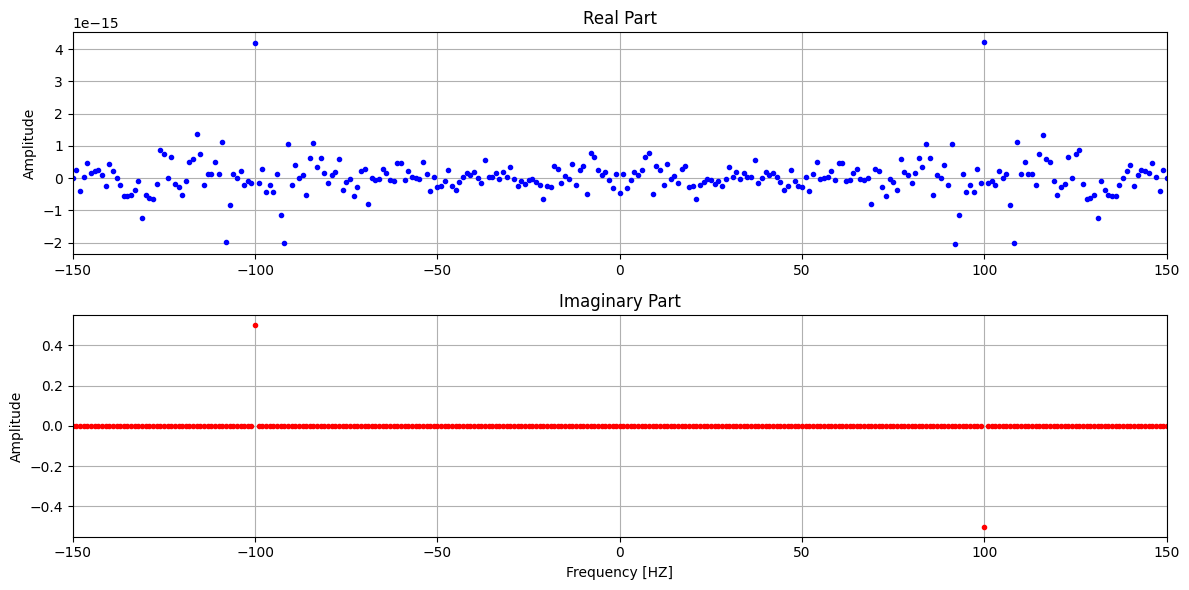

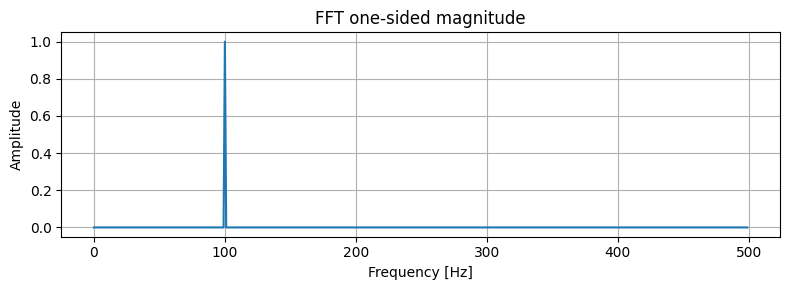

In [4]:


# Edit these parameters to get a feel of creating a signal

Fs = 1000      # sampling rate Hz
T  = 1.0       # duration s
f1, f2 = 100, 0
A1, A2 = 1.0, 0.5
noise_std = 0.0


def make_signal(Fs=1000, T=1.0, f1=50, f2=120, A1=1.0, A2=0.5, noise_std=0.0, seed=None):
    """
    Create a 2-tone sinusoidal signal with optional Gaussian noise.

    Returns:
        t : time array [s] with samples over [0, T)
        x : signal array
        N : number of samples
    """
    # TODO 1: compute number of samples N from Fs and T 
    N = int(Fs * T)
    # TODO 2: build time vector t of length N over [0, T)
    t = np.linspace(0, T, N, endpoint=False)
    
    # Optional noise generator for more realistic signal
    rng = np.random.default_rng(seed)

    # TODO 3: construct 2-tone signal:
    # x(t) = A1*sin(2*pi*f1*t) + A2*sin(2*pi*f2*t) + Gaussian noise
    x = np.zeros(N)
    x = A1 * np.sin(2*np.pi*f1*t) + A2 * np.sin(2*np.pi*f2*t)

    # Hint: rng.standard_normal(N) gives N(0,1) noise; scale by noise_std
    if noise_std != 0.0:
      x = x + (rng.standard_normal(N) * noise_std)

    return t, x, N


# Generate a signal 
t, x, N = make_signal(Fs=Fs, T=T, f1=f1, f2=f2, A1=A1, A2=A2, noise_std=noise_std, seed=0)

# Quick sanity checks 
dt = 1 / Fs
df = Fs / N
print(f"N = {N}, dt = {dt:.6f} s, df = {df:.3f} Hz")


# FFT computation
# TODO 4: compute the FFT of x 
X = np.fft.fft(x)

# TODO 5: build the frequency axis in Hz to freqs
freq = np.fft.fftfreq(N, 1/Fs)


# TODO 6: Plot both real and imaginary parts vs frequency
real_part = np.real(X) / N
imag_part = np.imag(X) / N

plt.figure(figsize=(12, 6))
# real
plt.subplot(2, 1, 1)
plt.plot(freq, real_part, marker='.', linestyle='none', color='blue')
plt.title('Real Part')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(-150, 150)
#imaginary
plt.subplot(2, 1, 2)
plt.plot(freq, imag_part, marker='.', linestyle='none', color='red')
plt.title('Imaginary Part')
plt.xlabel('Frequency [HZ]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(-150, 150)

plt.tight_layout()
plt.show()

# TODO 7: Plot only real part vs frequency


# One-sided magnitude plot
def plot_spectrum(X, Fs, title="One-sided magnitude spectrum"):
    """
    Plot a one-sided magnitude spectrum 

    """
    N = X.size

    # TODO 8: build frequency axis in Hz using np.fft.fftfreq
    freqs = np.fft.fftfreq(N, 1/Fs)

    # TODO 9: mask non-negative frequencies
    mask = freqs >= 0

    # TODO 10: compute magnitude 
    mag = (2.0 / N) * np.abs(X)

    plt.figure(figsize=(8, 3))
    plt.plot(freqs[mask], mag[mask])
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()



plot_spectrum(X, Fs, title="FFT one-sided magnitude")

1) Explain what the real and imaginary parts represent physically

2) Why does the FFT of a real-valued signal produce a symmetric pattern around 0 Hz?

3) Identify the frequencies of the main peaks and explain why they occur there.

4) Why do we divide by (N/2) when plotting the magnitude? What does this scaling represent?


Learning Outcome: Allows the student to understand the difference between the DFT and the FFT by manually implementing the DFT. From this the student will observe the computation expense of the DFT and why the FFT was developed. The questions aim to dig into the intuition of the Fourier Transform rather than giving the student a surface level understanding by calling np.fft.fft(X).

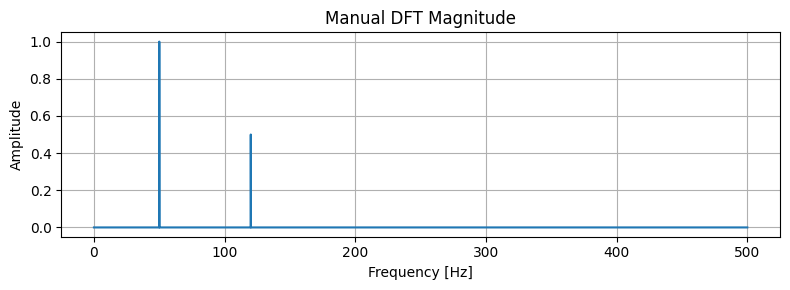

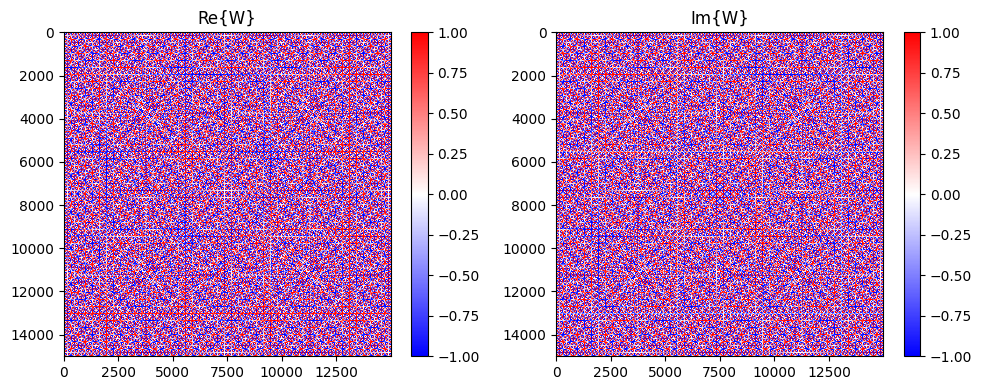

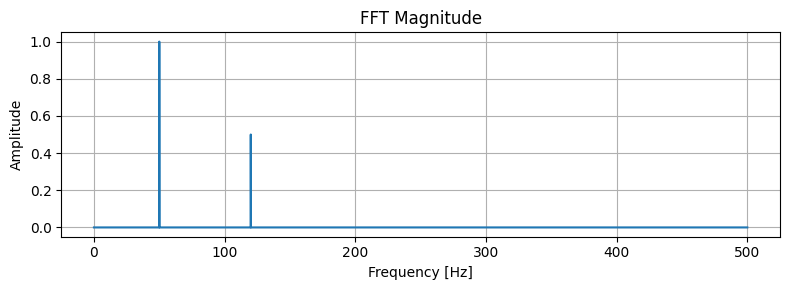

In [5]:

# DFT matrix 
def dft_matrix(N):
    """
    Build the NxN DFT matrix:
        W[k, n] = exp(-j 2 pi k n / N)
    """
    # TODO: create index arrays k (Nx1) and n (1xN)
    W = np.zeros((N, N), dtype=complex)

    # TODO: fill in the exponential for W (use 1j for j = sqrt(-1))
    for i in range(0, N):
      for j in range(0, N):
        W[i, j] = np.exp(-1j * (2 * np.pi * i * j / N))

    return W


# Manual DFT          
def manual_dft(x):
    """
    Compute the DFT via matrix-vector multiply:
        X = W @ x
    """
    N = x.size
    W = dft_matrix(N)
    # TODO: perform the matrix-vector multiply
    X = W @ x
    return X, W


def show_dft_matrix(W):
    """
    Visualize Re{W} and Im{W} as heatmaps. Red=positive, Blue=negative.
    """
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(np.real(W), aspect="auto", cmap="bwr", interpolation="nearest")
    plt.title("Re{W}")
    plt.colorbar()
    plt.subplot(1, 2, 2)
    plt.imshow(np.imag(W), aspect="auto", cmap="bwr", interpolation="nearest")
    plt.title("Im{W}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


# TODO: choose parameters 
Fs = 1000    
T  = 1.0       
f1 = 50        
f2 = 120       
A1, A2 = 1.0, 0.5
noise = 0.0

# Build signal
t, x, N = make_signal(Fs=Fs, T=T, f1=f1, f2=f2, A1=A1, A2=A2, noise_std=noise)

# Manual DFT
X_manual, W = manual_dft(x)
plot_spectrum(X_manual, Fs, title="Manual DFT Magnitude")
show_dft_matrix(W)

# TODO: compute FFT of x and compare with manual DFT
X_fft = np.fft.fft(x)

# TODO: Plot the FFT now and compare this against your manual implementation
plot_spectrum(X_fft, Fs, title="FFT Magnitude")

Look at the heatmaps of the real and imaginary parts of the DFT matrix W.

1) What do the colour patterns along each row represent in terms of sinusoidal frequency?

2) Explain why the DFT matrix can be interpreted as a set of basis sinusoids for analysing the signal.

3) Explain why the FFT produces the same result as the manual DFT but runs much faster.

4) How does changing the number of samples or sampling rate affect the resolution and spacing of frequency bins?

Learning Outcome: The student will now create a simple filter which will mask high frequencies. This will allow the understanding of transforming the signal from the time domain into the frequency domain which will then will be altered here. Once altered the signal will then be transformed back into the time domain by taking the inverse FFT. The reconstruction will be analysed using the signal noise ratio.

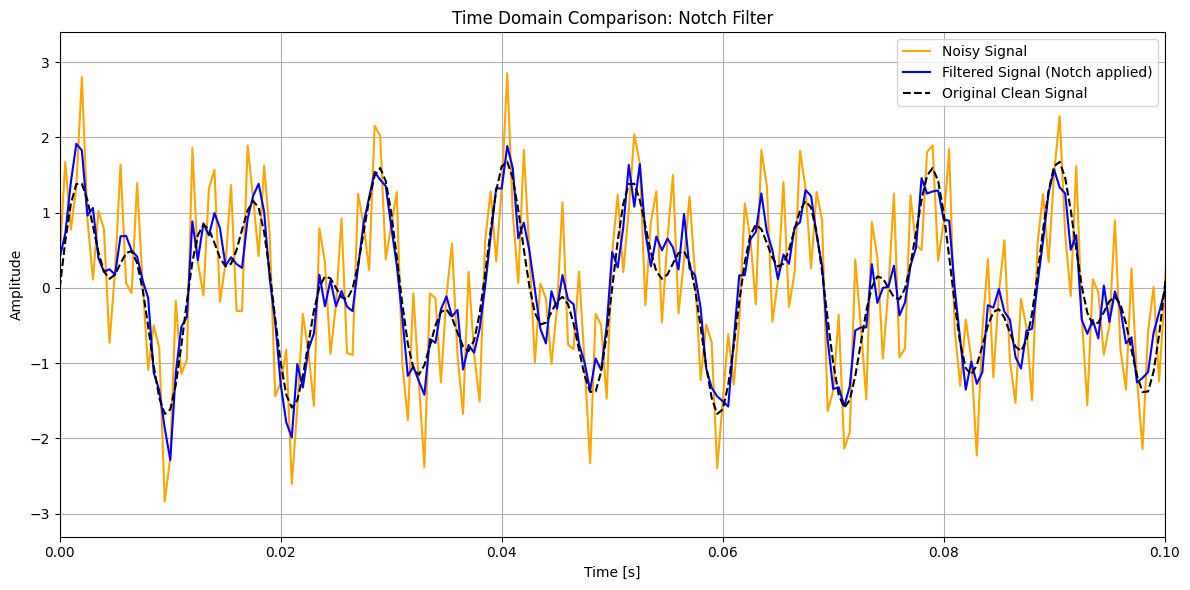

Original Bandpower: 89850.93099157984
Filtered Bandpower: 0.0
Suppression: -inf


In [6]:
def make_signal(Fs, T, f1=80, f2=180, A1=1.0, A2=0.7, f_noise=600, A_noise=1.0, noise_std=0.2):
    N = int(Fs * T)
    t = np.arange(N) / Fs
    x_clean = A1*np.sin(2*np.pi*f1*t) + A2*np.sin(2*np.pi*f2*t)
    pitched = A_noise*np.sin(2*np.pi*f_noise*t)
    x = x_clean + pitched + noise_std*np.random.randn(N)
    return t, x_clean, x, N

Fs = 2000
T  = 1.0

f1, f2 = 80, 180
A1, A2 = 1.0, 0.7

f_noise   = 600     # pitched interference
A_noise   = 1.0
noise_std = 0.25

notch_bw = 5.0      # half-width of notch in Hz 


rng = np.random.default_rng(0)
np.random.seed(0)  

t, x_clean, x, N = make_signal(Fs, T, f1, f2, A1, A2, f_noise, A_noise, noise_std)


X = np.fft.rfft(x)
freqs = np.fft.rfftfreq(N, d=1/Fs)


mask = np.ones_like(freqs, dtype=float)

# TODO implement notch: set mask=0 inside [f_noise - notch_bw, f_noise + notch_bw]
mask[(freqs >= f_noise - notch_bw) & (freqs <= f_noise + notch_bw)] = 0

# TODO Inverse FFT back to time
X_filtered = X * mask
x_rev = np.fft.irfft(X_filtered, n=N)

# TODO Plots: time domain
# TODO Plots: frequency domain before/after + show mask
plt.figure(figsize=(12, 6))

plt.plot(t, x, label='Noisy Signal', color='orange')
plt.plot(t, x_rev, label='Filtered Signal (Notch applied)', color='blue')
plt.plot(t, x_clean, label='Original Clean Signal', color='black', linestyle='--')

plt.title('Time Domain Comparison: Notch Filter')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.grid(True)

plt.xlim(0, 0.1)
plt.tight_layout()
plt.show()

#TODO write a function which compares the bandpower and then reports the suppression within the notched area
def calculate_notch_supression(freqs, X_orig, X_filt, f_center, notch_bw):
  # create a boolean mask fro frequency band
  band_indices = (freqs >= f_center - notch_bw) & (freqs <= f_center + notch_bw)

  # calculate bandpower
  power_orig = np.mean(np.abs(X_orig[band_indices])**2)
  power_filt = np.mean(np.abs(X_filt[band_indices])**2)

  # case where the filter zeroes out the power completely
  if power_filt == 0:
    supression_db = -np.inf
  else:
    supression_db = 10*np.log10(power_filt/power_orig)

  # logging
  print(f"Original Bandpower: {power_orig}")
  print(f"Filtered Bandpower: {power_filt}")
  print(f"Suppression: {supression_db}")

  return power_orig, power_filt, supression_db

p_orig, p_filt, supp_db = calculate_notch_supression(freqs, X, X_filtered, f_noise, notch_bw)


Inspect the plots of the noisy and denoised signals in both time and frequency domains.

1) What effect does the low-pass cutoff f_cut have on the signal’s spectrum?

2) How does this relate to the suppresion of the bandpower and what does the suppresion in dB represent?

3) In your FFT-based notch, the frequency bin spacing is $\Delta f = \frac{F_s}{N}$.
(a) Explain how $\Delta f$ limits how precisely you can target a narrow interference frequency.
(b) If the interference frequency is not exactly centered on an FFT bin, why does spectral leakage occur, and how would windowing change the leakage and the notch design?


Learning Outcomes: Demonstrate how the FFT can be used to compute derivatives and allow the student to understand why the Fourier Transform proivides a more accurate derivative compared to the finite difference method by expanding the signal in global sinusoids. This should also provide the student with an understanding of the power of the Fourier Transform. 

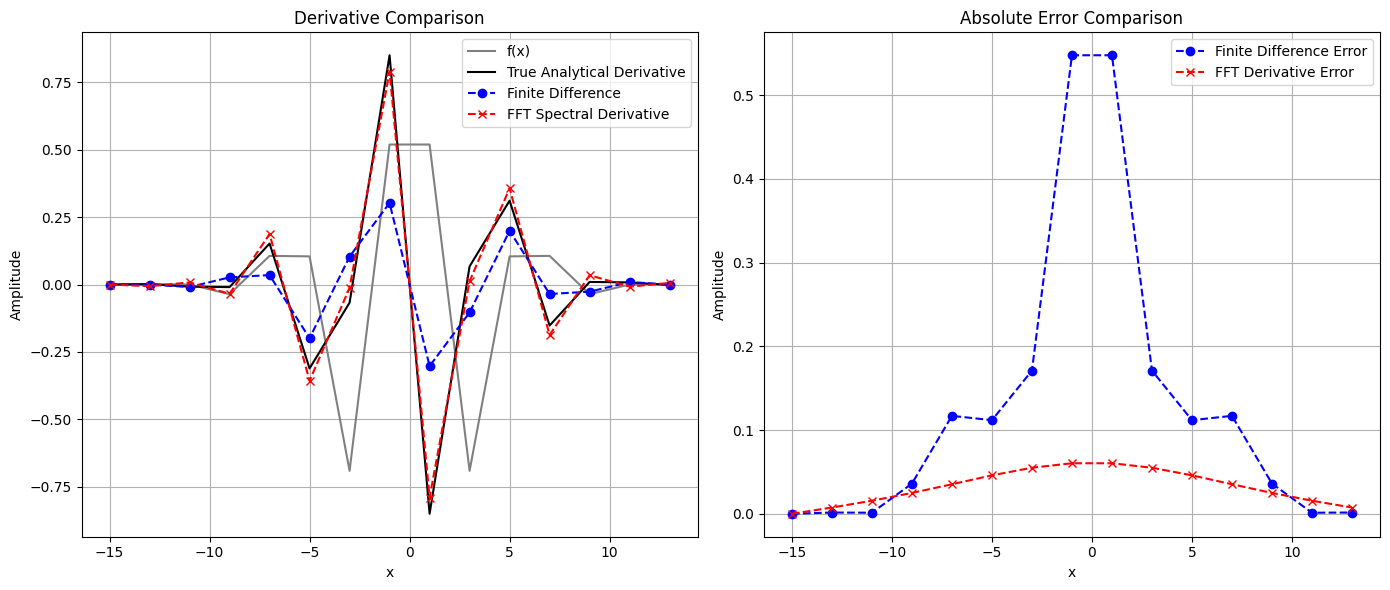

In [7]:

n = 15      # number of grid points
L = 30         # domain length
dx = L / n     # grid spacing
x = np.linspace(-L/2, L/2 - dx, n)  # uniform grid

#Function and true derivative
f = np.cos(x) * np.exp(-x**2 / 25)
df_true = ( -np.sin(x) * np.exp(-x**2 / 25) + ( -2*x/25 ) * np.cos(x) * np.exp(-x**2 / 25) )

# TODO: implement finite difference method for computing a derivative
#Finite difference derivative 
# 2nd order central finite difference
df_fd = (np.roll(f, -1) - np.roll(f, 1)) / (2 * dx)

# TODO: Compute the derivative using fft
# FFT derivative
fhat = np.fft.fft(f)

kp = 2 * np.pi * np.fft.fftfreq(n, d=dx)

dfhat = 1j * kp * fhat

# TODO: Inverse fourier transform to return this back into physical space
df_fft = np.fft.ifft(dfhat).real

# TODO: Plot results
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(x, f, color='gray', label='f(x)')
plt.plot(x, df_true, 'k-', label='True Analytical Derivative')
plt.plot(x, df_fd, 'b--', marker='o', label='Finite Difference')
plt.plot(x, df_fft, 'r--', marker='x', label='FFT Spectral Derivative')

plt.title('Derivative Comparison')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# TODO: Plot error metrics
error_fd = np.abs(df_true - df_fd)
error_fft = np.abs(df_true - df_fft)

plt.subplot(1, 2, 2)
plt.plot(x, error_fd, 'b--', marker='o', label='Finite Difference Error')
plt.plot(x, error_fft, 'r--', marker='x', label='FFT Derivative Error')

plt.title('Absolute Error Comparison')
plt.xlabel('x')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Look at the plotted results of the true derivative, the finite-difference derivative, and the FFT derivative.

1) Which method gives a closer match to the true derivative (try changing N to see this effect more clearly)?

2) Explain why this method performs better, based on how each approach computes derivatives.
